<a href="https://colab.research.google.com/github/Annette-1/Ecuaciones_Diferenciales_Parciales/blob/main/Linea_de_espera_dos_Servidores.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  <span style="color:purple;">**6.3 Sistema de línea de espera con dos servidores en serie** (libro de Ross)</span>


<span style="color:teal;">**Nombre:** </span> Jerónimo López Annette Michelle

<span style="color:teal;"> **Objetivo:**</span>

Consideremos un sistema de dos servidores en el que los clientes llegan de acuerdo con un proceso Poisson no homogéneo, y supongamos que cada llegada debe ser atendida primero por el servidor 1 y, al terminar el servicio en 1, el cliente pasa al servidor 2.

Tal sistema es un sistema de cola en **tándem** o **secuencial**.

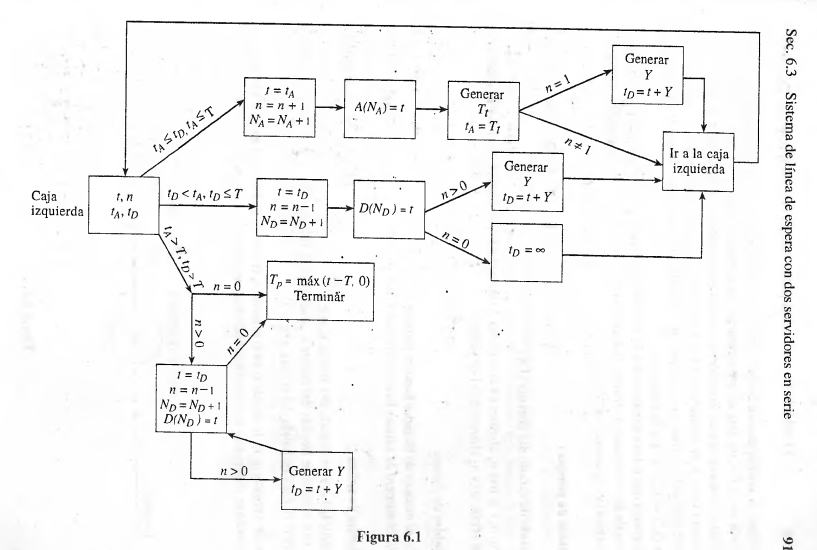

Al llegar, el cliente pasará con el servidor 1 si éste se encuentra desocupado, o se formará en la fila de éste en caso contrario. De manera análoga, cuando el cliente termine el servicio en el servidor 1, entra a servicio con el servidor 2 si éste se encuentra libre, o se formará en su fila. Después de ser atendido en el servidor 2, el cliente sale del sistema. Los tiempos de servicio en el servidor $i$ tienen la distribución $G_i$, $i = 1,2$ (véase la figura 6.2).

Suponga que estamos interesados en realizar una simulación para estudiar la distribución de las cantidades de tiempo que un cliente pasa en ambos servidores. Para esto, utilizamos las siguientes variables.

### Variable de tiempo

$t$

### Variable de estado del sistema (ES)

$(n_1, n_2)$:

si hay $n_1$ clientes en el servidor 1 (incluyendo los formados y los que están en servicio) y $n_2$ clientes en el servidor 2.

### Variables de conteo

$N_A$: el número de llegadas hasta el instante $t$

$N_D$: el número de salidas hasta el instante $t$

### Variables de salida

$A_1(n)$: la hora de llegada del cliente $n$, $n \geq 1$

$A_2(n)$: la hora de llegada del cliente $n$ al servidor 2, $n \geq 1$

$D(n)$: la hora de salida del cliente $n$, $n \geq 1$

### Lista de eventos

$t_A, t_1, t_2$, donde $t_A$ es la hora de la siguiente llegada y $t_i$ es la hora a la que concluye el servicio del cliente actualmente atendido por el servidor $i$, $i = 1,2$.

Si en un momento dado no se encuentra un cliente con el servidor $i$, entonces

$$
t_i = \infty, \quad i = 1,2.
$$

La lista de eventos siempre consta de las tres variables $t_A$, $t_1$, $t_2$.

Para comenzar la simulación, inicializamos las variables y la lista de eventos como sigue:

### Inicialización

Sean

$$
t = N_A = N_D = 0.
$$

Sea el estado del sistema

$$
ES = (0,0).
$$

Generar $T_0$ y hacer

$$
t_A = T_0,
\qquad
t_1 = t_2 = \infty.
$$

Para actualizar el sistema, nos movemos en el tiempo hasta encontrar el siguiente evento. Debemos considerar diversos casos, dependiendo del mínimo de los miembros de la lista de eventos. En lo sucesivo, $Y_i$ se refiere a una variable aleatoria con distribución $G_i$, $i=1,2$.

$$
ES=(n_1,n_2)
\qquad
LE=t_A,t_1,t_2
$$

## Caso 1

$$
t_A=\min(t_A,t_1,t_2)
$$

Restablecer:

$$
t=t_A
$$

Restablecer:

$$
N_A=N_A+1
$$

Restablecer:

$$
n_1=n_1+1
$$

Generar $T_r$ y hacer

$$
t_A=T_r
$$

Si $n_1=1$, generar $Y_1$ y hacer

$$
t_1=t+Y_1
$$

Reunir los datos de salida

$$
A_1(N_A)=t
$$

## Caso 2

$$
t_1<t_A,\qquad t_1\le t_2
$$

Restablecer:

$$
t=t_1
$$

Restablecer:

$$
n_1=n_1-1,
\qquad
n_2=n_2+1
$$

Si $n_1=0$, hacer

$$
t_1=\infty
$$

En caso contrario, generar $Y_1$ y hacer

$$
t_1=t+Y_1
$$

Si $n_2=1$, generar $Y_2$ y hacer

$$
t_2=t+Y_2
$$

Reunir los datos de salida

$$
A_2(N_A-n_1)=t
$$

## Caso 3

$$
t_2<t_A,\qquad t_2<t_1
$$

Restablecer:

$$
t=t_2
$$

Restablecer:

$$
N_D=N_D+1
$$

Restablecer:

$$
n_2=n_2-1
$$

Si $n_2=0$, hacer

$$
t_2=\infty
$$

Si $n_2>0$, generar $Y_2$ y hacer

$$
t_2=t+Y_2
$$

Reunir los datos de salida

$$
D(N_D)=t
$$

Con este esquema de actualización, es fácil simular el sistema y reunir los datos de importancia.

In [ ]:
import numpy as np
from dataclasses import dataclass

In [ ]:
@dataclass
class EstadoSistema:
    """
    Estado del sistema.

    n1 : clientes en servidor 1
         (en cola + servicio)

    n2 : clientes en servidor 2
         (en cola + servicio)

    NA : número de llegadas

    ND : número de salidas

    t  : tiempo actual
    """

    n1: int = 0
    n2: int = 0

    NA: int = 0
    ND: int = 0

    t: float = 0.0

In [ ]:
def generar_llegada(lamb):
    """
    Tiempo hasta la siguiente llegada.
    """
    return np.random.exponential(1/lamb)


def generar_servicio1(mu1):
    """
    Tiempo de servicio en servidor 1.
    """
    return np.random.exponential(1/mu1)


def generar_servicio2(mu2):
    """
    Tiempo de servicio en servidor 2.
    """
    return np.random.exponential(1/mu2)

In [ ]:
def inicializar(lamb):
    """
    Inicializa variables del sistema.
    """

    estado = EstadoSistema()

    # Próxima llegada
    tA = generar_llegada(lamb)

    # No hay clientes en servicio
    t1 = np.inf
    t2 = np.inf

    return estado, tA, t1, t2

In [ ]:
def evento_llegada(
        estado,
        tA,
        t1,
        t2,
        lamb,
        mu1,
        A1):
    """
    Procesa una llegada al sistema.
    """

    estado.t = tA

    estado.NA += 1

    estado.n1 += 1

    cliente = estado.NA

    # Registrar hora de llegada
    A1[cliente] = estado.t

    # Programar siguiente llegada
    tA = estado.t + generar_llegada(lamb)

    # Si servidor 1 estaba vacío
    if estado.n1 == 1:

        y1 = generar_servicio1(mu1)

        t1 = estado.t + y1

    return tA, t1, t2

In [ ]:
def evento_servidor1(
        estado,
        tA,
        t1,
        t2,
        mu1,
        mu2,
        A2):
    """
    Cliente termina servicio en servidor 1.
    """

    estado.t = t1

    estado.n1 -= 1
    estado.n2 += 1

    # Servidor 1
    if estado.n1 == 0:

        t1 = np.inf

    else:

        y1 = generar_servicio1(mu1)

        t1 = estado.t + y1

    # Servidor 2
    if estado.n2 == 1:

        y2 = generar_servicio2(mu2)

        t2 = estado.t + y2

    cliente = estado.NA - estado.n1

    A2[cliente] = estado.t

    return tA, t1, t2

In [ ]:
def evento_servidor2(
        estado,
        tA,
        t1,
        t2,
        mu2,
        D):
    """
    Cliente abandona el sistema.
    """

    estado.t = t2

    estado.ND += 1

    estado.n2 -= 1

    cliente = estado.ND

    D[cliente] = estado.t

    if estado.n2 == 0:

        t2 = np.inf

    else:

        y2 = generar_servicio2(mu2)

        t2 = estado.t + y2

    return tA, t1, t2

In [ ]:
def simular_tandem(
        lamb,
        mu1,
        mu2,
        n_clientes):
    """
    Simulación de cola en serie con dos servidores.
    """

    estado, tA, t1, t2 = inicializar(lamb)

    A1 = {}
    A2 = {}
    D = {}

    while estado.ND < n_clientes:

        minimo = min(tA, t1, t2)

        # Caso 1
        if minimo == tA:

            tA, t1, t2 = evento_llegada(
                estado,
                tA,
                t1,
                t2,
                lamb,
                mu1,
                A1
            )

        # Caso 2
        elif minimo == t1:

            tA, t1, t2 = evento_servidor1(
                estado,
                tA,
                t1,
                t2,
                mu1,
                mu2,
                A2
            )

        # Caso 3
        else:

            tA, t1, t2 = evento_servidor2(
                estado,
                tA,
                t1,
                t2,
                mu2,
                D
            )

    return A1, A2, D

In [ ]:
np.random.seed(123)

A1, A2, D = simular_tandem(
    lamb=2,
    mu1=3,
    mu2=4,
    n_clientes=10
)

print("Llegadas al sistema")
for k, v in A1.items():
    print(k, round(v,4))

print("\nLlegadas al servidor 2")
for k, v in A2.items():
    print(k, round(v,4))

print("\nSalidas del sistema")
for k, v in D.items():
    print(k, round(v,4))

Llegadas al sistema
1 0.5961
2 0.7647
3 1.4002
4 1.9775
5 2.1877
6 2.4763
7 3.146
8 3.5255
9 4.17
10 4.365
11 4.5389
12 4.5872

Llegadas al servidor 2
1 0.6819
2 0.948
3 1.6188
4 2.4128
5 2.4333
6 2.5435
7 3.4814
8 3.8402
9 4.3197
10 4.6973

Salidas del sistema
1 0.8823
2 1.9358
3 2.0602
4 2.5397
5 2.5879
6 2.7775
7 3.9548
8 4.2752
9 4.3845
10 4.8675


In [ ]:
W1 = {
    n: A2[n]-A1[n]
    for n in A2
}

In [ ]:
W2 = {
    n: D[n]-A2[n]
    for n in D
}

In [ ]:
T = {
    n: D[n]-A1[n]
    for n in D
}

print(
    "Tiempo promedio en sistema:",
    np.mean(list(T.values()))
)

Tiempo promedio en sistema: 0.5656187707299114
